## Import thư viện

In [1]:
import WOEpyspark as woe
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

## Khởi tạo SparkSession

In [2]:
spark = SparkSession.builder \
    .appName("woe_analysis") \
    .master("local[4]") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Load dữ liệu

In [3]:
# Load data
sdf = spark.read.parquet("feature_S5.parquet")

# Split train/test
train_sdf, test_sdf = woe.stratified_sklearnsplit(sdf, label_col="LABEL")


c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Tính raw WOE, IV với 100 bins

In [4]:
FEATURE_NAME = "TIEN_VA_TIEN_TUONG_DUONG_CK"

In [5]:
# Compute WoE/IV for a continuous variable (auto-binning)
df_woe_cont = woe.woe_continuous(train_sdf, FEATURE_NAME, "LABEL", n_bins=100)

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [6]:
df_woe_cont.head(5)

,TIEN_VA_TIEN_TUONG_DUONG_CK,n_obs,prop_card,n_card,n_non_card,prop_n_obs,prop_n_card,prop_n_non_card,WoE,IV_bin,IV,diff_prop_card,diff_WoE
0,MISSING,15892,0.003398,54.0,15838.0,0.259135,0.191564,0.259030,-0.301720,0.020356,0.311465,NaN,NaN
1,ZERO,164,0.006098,1.0,163.0,0.002674,0.005272,0.002674,0.678930,0.001764,0.311465,0.002700,0.980650
2,"(-107113033579.0,2271740.0]",452,0.008850,4.0,448.0,0.007370,0.015817,0.007335,0.768447,0.006518,0.311465,0.002752,0.089517
3,"(-107113033579.0,-107113033579.0]",1,0.000000,0.0,1.0,0.000016,0.001757,0.000025,4.271666,0.007403,0.311465,0.008850,3.503219
4,"(2271740.0,11780585.0]",453,0.002208,1.0,452.0,0.007387,0.005272,0.007400,-0.339044,0.000721,0.311465,0.002208,4.610710


## Vẽ biểu đồ WOE raw

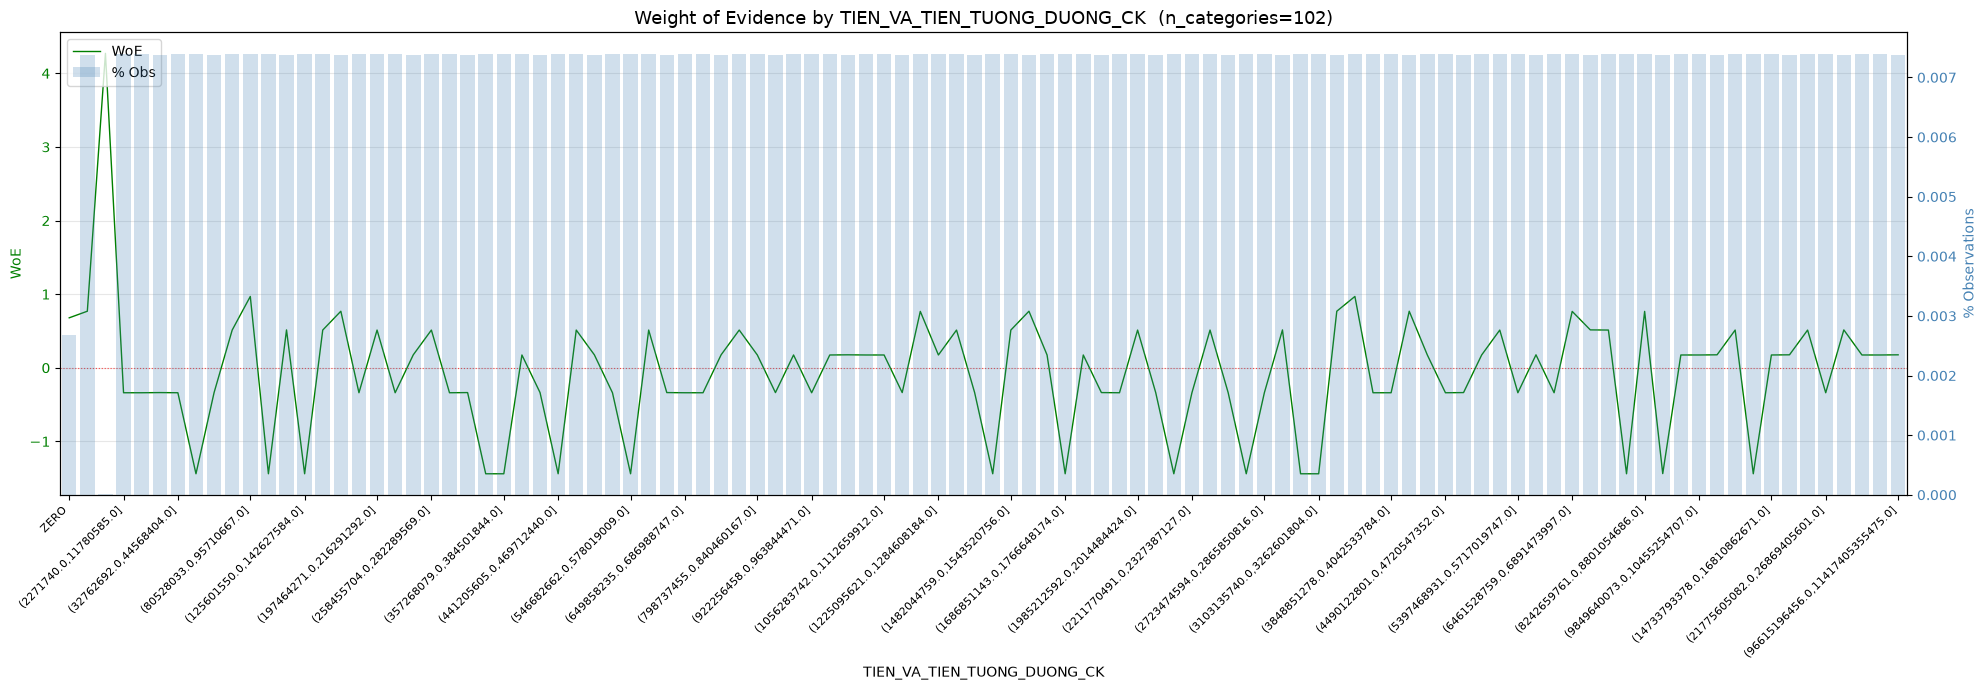

In [7]:
# Plot WoE chart (hiding MISSING for clearer view)
fig2 = woe.plot_woe_missing(df_woe_cont)

## Chia thủ công các bin

In [8]:
# Define bins once
bins = [
    (300_000_000, "(-inf, 300M]"),
    (850_000_000, "(300M, 850M]"),
    (2_000_000_000, "(850M, 2B]"),
    (5_500_000_000, "(2B, 5.5B]"),
    (np.inf, "(5.5B, +inf)")
]

col = F.col(FEATURE_NAME)

bin_expr = (
    F.when(col.isNull(), "MISSING")
     .when(col == 0, "ZERO")
)

for upper, label in bins:
    if np.isinf(upper):
        bin_expr = bin_expr.otherwise(label)
    else:
        bin_expr = bin_expr.when(col < upper, label)

train_sdf = train_sdf.withColumn(
    "TIEN_VA_TIEN_TUONG_DUONG_CK_BIN",
    bin_expr
)
df_manual = woe.woe_discrete(train_sdf, FEATURE_NAME + "_BIN")

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Vẽ biểu đồ WOE sau khi chia bins

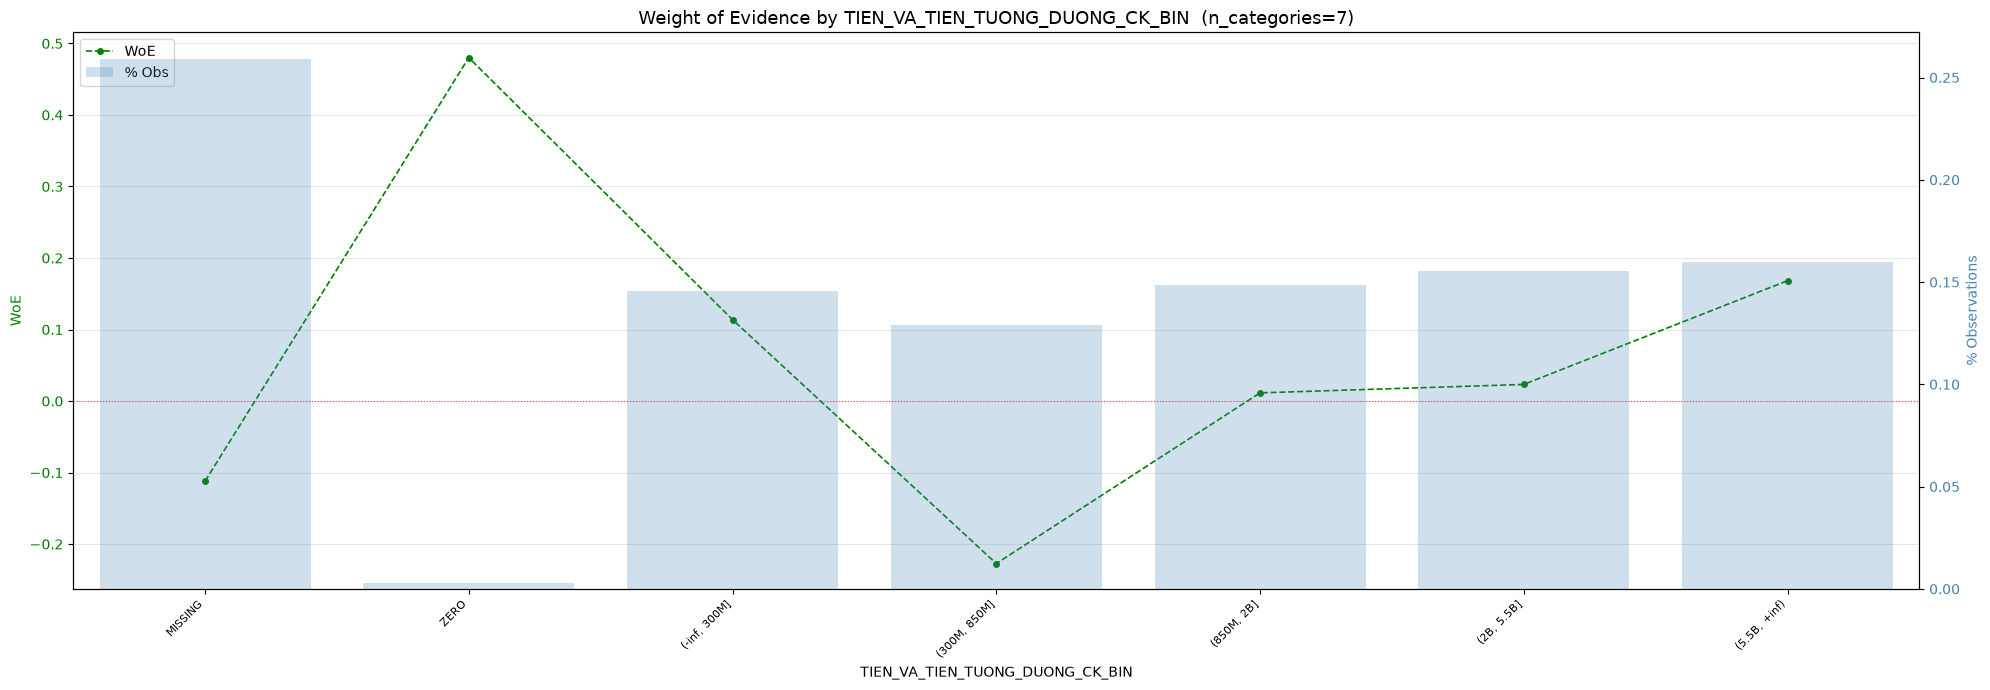

In [9]:
fig_manualdefine = woe.plot_woe(df_manual)


## Bảng kết quả của 3 trường hợp 
Bảng chứa MISSING, không chứa MISSING, và MISSING riêng

In [10]:
# Build 3 cases: FULL, MISSING_VS_REST, NO_MISSING
cases = woe.build_three_cases(df_manual, missing_label="MISSING")

print("Case A - Full IV:", cases["full"])
type(cases["full"])


Case A - Full IV:   TIEN_VA_TIEN_TUONG_DUONG_CK_BIN  n_obs  prop_card  prop_n_obs  n_card  \
0                         MISSING  15892   0.003398    0.259135    54.0   
1                            ZERO    164   0.006098    0.002674     1.0   
2                    (-inf, 300M]   8930   0.004255    0.145613    38.0   
3                    (300M, 850M]   7923   0.003029    0.129193    24.0   
4                      (850M, 2B]   9108   0.003843    0.148515    35.0   
5                      (2B, 5.5B]   9516   0.003888    0.155168    37.0   
6                    (5.5B, +inf)   9794   0.004493    0.159701    44.0   

   n_noncard  n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard  \
0    15838.0         54.005         15838.005     0.231746        0.259240   
1      163.0          1.005           163.005     0.004313        0.002668   
2     8892.0         38.005          8892.005     0.163087        0.145546   
3     7899.0         24.005          7899.005     0.103010        0.1

pandas.DataFrame

In [11]:
print("Case B - Missing vs Rest IV:", cases["missing_vs_rest"])

Case B - Missing vs Rest IV:   TIEN_VA_TIEN_TUONG_DUONG_CK_BIN  n_obs  prop_card  prop_n_obs  n_card  \
0                         MISSING  15892   0.003398    0.259135    54.0   
1                     NON_MISSING  45435   0.003940    0.740865   179.0   

   n_noncard  n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard  \
0    15838.0         54.005         15838.005     0.231771         0.25924   
1    45256.0        179.005         45256.005     0.768229         0.74076   

        WoE  diff_prop_card  diff_WoE  IV_detail        IV  
0 -0.112003             NaN       NaN   0.003077  0.004077  
1  0.036411        0.000542  0.148414   0.001000  0.004077  


In [12]:
print("Case C - No Missing IV:", cases["no_missing"])

Case C - No Missing IV:   TIEN_VA_TIEN_TUONG_DUONG_CK_BIN  n_obs  prop_card  prop_n_obs  n_card  \
0                            ZERO    164   0.006098    0.003610     1.0   
1                    (-inf, 300M]   8930   0.004255    0.196545    38.0   
2                    (300M, 850M]   7923   0.003029    0.174381    24.0   
3                      (850M, 2B]   9108   0.003843    0.200462    35.0   
4                      (2B, 5.5B]   9516   0.003888    0.209442    37.0   
5                    (5.5B, +inf)   9794   0.004493    0.215561    44.0   

   n_noncard  n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard  \
0      163.0          1.005           163.005     0.005614        0.003602   
1     8892.0         38.005          8892.005     0.212283        0.196482   
2     7899.0         24.005          7899.005     0.134084        0.174540   
3     9073.0         35.005          9073.005     0.195526        0.200482   
4     9479.0         37.005          9479.005     0.206697  

## Lưu kết quả và tổng hợp qua file HTML

In [13]:
# CSV only
woe.save_iv_csv(cases, "output/iv_cases.csv")

# HTML with plot
woe.save_iv_html(
    iv_dict=cases,
    plots={"WoE_Chart": fig2, "Binned_Chart": fig_manualdefine},
    output_path="output/iv_cases.html",
    title="IV Summary"
)

'output/iv_cases.html'